# DS 5001 Final Project

Erin Siedlecki

## Models

In [46]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
np.random.seed(42)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/erinsiedlecki/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [47]:
LIB = pd.read_csv('../data/LIB.csv', sep='|')
VOCAB = pd.read_csv('../data/VOCAB.csv', sep='|', index_col='term_str')
CORPUS = pd.read_csv('../data/CORPUS.csv', sep='|')
OHCO = ['artist', 'song', 'token_num']
CORPUS = CORPUS.set_index(OHCO)
BOW = pd.read_csv('../data/BOW.csv', sep='|')
DTM = pd.read_csv('../data/DTM.csv', sep='|', index_col=[0,1])
TFIDF = pd.read_csv('../data/TFIDF.csv', sep='|', index_col=[0,1])
TFIDF_L2 = pd.read_csv('../data/TFIDF_L2.csv', sep='|', index_col=[0,1])

## PCA Components

In [48]:
from sklearn.decomposition import PCA

pca_engine = PCA(n_components=10, random_state=42)
PCA_DCM = pd.DataFrame(pca_engine.fit_transform(TFIDF_L2), index=TFIDF_L2.index)
PCA_DCM.columns = ['PC{}'.format(i) for i in range(10)]

PCA_LOADINGS = pd.DataFrame(pca_engine.components_.T, index=TFIDF_L2.columns)
PCA_LOADINGS.columns = ['PC{}'.format(i) for i in range(10)]
PCA_LOADINGS.index.name = 'term_str'

In [49]:
pos5_pc0 = PCA_LOADINGS['PC0'].sort_values(ascending=False).head(5).index.tolist()
neg5_pc1 = PCA_LOADINGS['PC1'].sort_values(ascending=True).head(5).index.tolist()
print(pos5_pc0, neg5_pc1)

['yeah', 'baby', 'love', 'girl', 'want'] ['one', 'never', 'home', 'would', 'could']


In [50]:
PCA_DCM.to_csv('../data/PCA_DCM.csv', sep='|', index=True)
PCA_LOADINGS.to_csv('../data/PCA_LOADINGS.csv', sep='|', index=True)

Number of components: 10

Library used to generate: scikit-learn

Top 5 positive terms for first component (PC0): ['yeah', 'baby', 'love', 'girl', 'want']

Top 5 negative terms for second component (PC1): ['one', 'never', 'home', 'would', 'could']

## PCA DCM

In [51]:
PCA_DCM.head(5)

PC0       PC1       PC2  \
artist        song                                                           
Ariana Grande -thank u, next (video version)  0.024794  0.075023  0.042878   
              34+35                           0.108295  0.193815 -0.028190   
              34+35 (DJ Siembab Remix)        0.112776  0.195192 -0.030028   
              34+35 (Remix)                   0.164301  0.250946  0.025435   
              34+35 (Remix) (Clean)           0.168218  0.238915  0.025523   

                                                   PC3       PC4       PC5  \
artist        song                                                           
Ariana Grande -thank u, next (video version)  0.052286 -0.017856  0.016294   
              34+35                          -0.081565 -0.074672 -0.107759   
              34+35 (DJ Siembab Remix)       -0.082812 -0.075956 -0.109513   
              34+35 (Remix)                  -0.033831 -0.041622 -0.050173   
              34+35 (Remix) (Clean)          -0.016997 -0.049200 -0.050128   

                                                   PC6       PC7       PC8  \
artist        song                                                           
Ariana Grande -thank u, next (video version)  0.087025 -0.119502 -0.100277   
              34+35                          -0.041089 -0.129768 -0.015561   
              34+35 (DJ Siembab Remix)       -0.042867 -0.130575 -0.015837   
              34+35 (Remix)                   0.066003 -0.164932 -0.073649   
              34+35 (Remix) (Clean)           0.056787 -0.139635 -0.073883   

                                                   PC9  
artist        song                                      
Ariana Grande -thank u, next (video version) -0.129629  
              34+35                          -0.085228  
              34+35 (DJ Siembab Remix)       -0.086767  
              34+35 (Remix)                  -0.168760  
              34+35 (Remix) (Clean)          -0.187988

## PCA Loadings

In [52]:
PCA_LOADINGS.head(5)

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
0,0.000324,0.004137,-0.000064,-0.007365,0.001481,-0.012149,-0.008709,-0.005222,0.000461,0.006754
00,-0.007299,0.001820,0.001908,0.001936,-0.000384,-0.000658,0.003238,-0.001155,-0.001046,-0.000641
000,-0.000167,0.000645,-0.000376,-0.000460,0.000105,0.001738,0.001972,0.001622,-0.001103,-0.001544
04,-0.005947,0.000860,0.000983,0.000061,-0.000243,-0.001070,-0.000271,-0.000257,-0.000481,-0.000303
05,-0.020191,0.007483,0.004471,0.001749,-0.001660,-0.006625,-0.004493,-0.001004,-0.000156,0.008895


## PCA Visualization 1

In [53]:
import plotly.express as px

def vis_pcs(DCM, a, b):
    plot_df = DCM.reset_index()
    return px.scatter(
        plot_df, f"PC{a}", f"PC{b}", 
        color='artist', 
        hover_name='song',
        marginal_x='box', height=800)

def vis_loadings(COMPS, a=0, b=1, hover_name='term_str'):
    return px.scatter(COMPS.reset_index(), f"PC{a}", f"PC{b}", 
                      text='term_str', 
                      marginal_x='box', 
                      height=800)

In [54]:
fig1 = vis_pcs(PCA_DCM, 0, 1)
fig1.write_image('../images/PCA_Visualization_1.png')
fig1.show()

In [55]:
load1 = vis_loadings(PCA_LOADINGS, 0, 1)
load1.write_image('../images/PCA_LOAD_Visualization_1.png')
load1.show()

Briefly describe the nature of the polarity you see in the first component:

Looking at the scatterplot of the DCM for PC0 and PC1, we see the majority of points are clustered together in the center, indicating similar word patterns amongst these songs. The scatterplot of the PCA loadings for PC0 and PC1 shows a large cluster in the center of the plot. Words such as "yeah", "baby", "girl", "want", "love", and "ooh", which are commonly repeated in lyrics, are spread out towards the right (positive) side of PC0. This indicates that PC0 is separating the high-frequency words common in pop songs on the positive side from the content-rich language on the negative side. 

## PCA Visualization 2

In [56]:
fig2 = vis_pcs(PCA_DCM, 1, 2)
fig2.write_image('../images/PCA_Visualization_2.png')
fig2.show()

In [57]:
load2 = vis_loadings(PCA_LOADINGS, 1, 2)
load2.write_image('../images/PCA_LOAD_Visualization_2.png')
load2.show()

Briefly describe the nature of the polarity you see in the second component:

The scatterplot of the DCM for PC1 and PC2 has a large cluster near the center, indicating similar word patterns across songs. The scatterplot of the PCA loadings of PC1 and PC2 also shows clustering near the center, with a few words extending outward. Terms such as "yeah", "ooh", and "hey" spread out towards the positive side, while terms such as "one", "new", "rules", and "count" spread out towards the negative side. This suggests that PC1 does have polarity, but the separation of repetitive lyrical terms from content-rich terms is relatively weak as there is a very large cluster in the center of the plot.

## LDA Topic

In [58]:
DOCS = CORPUS[CORPUS.pos.str.match(r'^NNS?$')]\
    .groupby(['artist', 'song']).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

In [59]:
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
LDA_VOCAB = pd.DataFrame(index=TERMS)
LDA_VOCAB.index.name = 'term_str'
LDA_DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
LDA_DTM

accident  act  \
artist        song                                                            
Ariana Grande -thank u, next (video version)                         0    0   
              34+35                                                  0    0   
              34+35 (DJ Siembab Remix)                               0    0   
              34+35 (Remix)                                          0    0   
              34+35 (Remix) (Clean)                                  0    0   
...                                                                ...  ...   
Taylor Swift  ​willow (original songwriting demo)                    0    0   
              ​willow [dancing witch version (Elvira remix)]         0    0   
              ​’tis the damn season                                  0    0   
              “Happy Voting! 🗳😃🌈”                                    0    0   
              “Songs Taylor Loves” Playlist                          0    0   

                                                              action  adam  \
artist        song                                                           
Ariana Grande -thank u, next (video version)                       0     0   
              34+35                                                0     0   
              34+35 (DJ Siembab Remix)                             0     0   
              34+35 (Remix)                                        0     0   
              34+35 (Remix) (Clean)                                0     0   
...                                                              ...   ...   
Taylor Swift  ​willow (original songwriting demo)                  0     0   
              ​willow [dancing witch version (Elvira remix)]       0     0   
              ​’tis the damn season                                0     0   
              “Happy Voting! 🗳😃🌈”                                  0     0   
              “Songs Taylor Loves” Playlist                        0     0   

                                                              adrenaline  \
artist        song                                                         
Ariana Grande -thank u, next (video version)                           0   
              34+35                                                    0   
              34+35 (DJ Siembab Remix)                                 0   
              34+35 (Remix)                                            0   
              34+35 (Remix) (Clean)                                    0   
...                                                                  ...   
Taylor Swift  ​willow (original songwriting demo)                      0   
              ​willow [dancing witch version (Elvira remix)]           0   
              ​’tis the damn season                                    0   
              “Happy Voting! 🗳😃🌈”                                      0   
              “Songs Taylor Loves” Playlist                            0   

                                                              advantage  \
artist        song                                                        
Ariana Grande -thank u, next (video version)                          0   
              34+35                                                   0   
              34+35 (DJ Siembab Remix)                                0   
              34+35 (Remix)                                           0   
              34+35 (Remix) (Clean)                                   0   
...                                                                 ...   
Taylor Swift  ​willow (original songwriting demo)                     0   
              ​willow [dancing witch version (Elvira remix)]          0   
              ​’tis the damn season                                   0   
              “Happy Voting! 🗳😃🌈”                                     0   
              “Songs Taylor Loves” Playlist                           0   

                                                      

In [60]:
from sklearn.decomposition import LatentDirichletAllocation as LDA

n_topics = 5
max_iter = 10
n_top_terms = 5
TNAMES = [f"T{str(x).zfill(2)}" for x in range(n_topics)]
topic_engine = LDA(n_components=n_topics, max_iter=max_iter, random_state=42)
topic_model = topic_engine.fit_transform(count_model)

In [61]:
LDA_DTM.to_csv('../data/LDA_DTM.csv', sep='|', index=True)

## Theta

In [62]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.head(5)

topic_id                                           T00       T01       T02  \
artist        song                                                           
Ariana Grande -thank u, next (video version)  0.898591  0.001472  0.001485   
              34+35                           0.001989  0.001984  0.002030   
              34+35 (DJ Siembab Remix)        0.001970  0.001965  0.002011   
              34+35 (Remix)                   0.085357  0.001583  0.001564   
              34+35 (Remix) (Clean)           0.085367  0.001644  0.001634   

topic_id                                           T03       T04  
artist        song                                                
Ariana Grande -thank u, next (video version)  0.001496  0.096957  
              34+35                           0.001994  0.992002  
              34+35 (DJ Siembab Remix)        0.001974  0.992080  
              34+35 (Remix)                   0.012516  0.898980  
              34+35 (Remix) (Clean)           0.001604  0.909752

In [63]:
THETA.to_csv('../data/LDA_THETA.csv', sep='|', index=True)

## PHI

In [64]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.head(5)

term_str,accident,act,action,adam,adrenaline,advantage,adventure,advice,affair,affection,...,york,youd,youll,youre,youth,youtube,youve,yuh,yup,zone
topic_id,,,,,,,,,,,,,,,,,,,,,
T00,13.092068,68.708413,12.065882,0.612479,4.526732,1.796246,6.079008,48.172967,0.205103,0.201161,...,6.390393,18.153259,23.948300,315.574400,28.659142,11.192831,22.891977,0.202462,21.767210,31.084589
T01,0.202152,5.518257,0.203454,0.202525,0.201165,0.202867,0.200002,0.201495,0.201098,0.209020,...,0.202584,0.209055,0.202943,0.203168,0.201358,0.201344,0.200208,0.200699,5.621163,6.270035
T02,0.200737,21.630126,0.203743,15.526809,0.201347,3.609957,8.319624,0.201144,8.399461,6.747962,...,104.798078,0.201925,0.445656,0.336743,3.735236,0.204659,0.201100,6.465983,0.203502,1.101757
T03,0.200565,0.201753,9.325811,4.547839,5.441209,0.204180,0.201172,0.426842,8.994261,36.409813,...,0.201719,14.232828,0.201183,38.322555,0.202401,0.201052,1.504466,1.564700,0.202628,0.338468
T04,0.304478,8.941451,0.201110,55.110348,4.629547,18.186750,0.200193,1.997552,0.200076,3.432044,...,13.407227,0.202934,0.201918,101.563133,0.201862,0.200113,0.202249,63.566156,0.205498,0.205150


In [65]:
PHI.to_csv('../data/LDA_PHI.csv', sep='|', index=True)

## LDA Topic Continued

In [66]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS_SORT = TOPICS.sort_values('doc_weight_sum', ascending=False)
TOPICS_SORT

,top_terms,doc_weight_sum,term_freq
topic_id,,,
T00,way cause man heart world,1276.291321,0.286345
T02,night time work oh cause,841.019862,0.192840
T04,yeah baby time boy cause,810.641666,0.211377
T03,love baby hey music way,607.541504,0.161815
T01,girl body girls dance cause,538.505647,0.147622


Libary used to compute: scikit-learn

A description of any filtering, e.g. POS (Nouns and Verbs only): I filtered to nouns only, removed stopwords, and retained terms in at least 10 songs (min_df=10).

Number of components: 5

Any other parameters used: max_df = 0.9, min_df = 10, stop_words = my_stop_words, max_iter = 10, random_state = 42


Top 5 words and best-guess labels for topic five topics by mean document weight:

T00: way cause man heart world; Label: Reflection

T01: girl body girls dance cause; Label: Dance, attraction

T02: night time work oh cause; Label: Life

T03: love baby hey music way; Label: Love

T04: yeah baby time boy cause; Label: Commonly repeated pop music language

## LDA + PCA Visualization

In [67]:
pca_topics = PCA(n_components=2, random_state=42)
THETA_T = THETA.T
PCA_TOPICS = pd.DataFrame(pca_topics.fit_transform(THETA_T), index=THETA_T.index,
                         columns=['PC0', 'PC1'])
PCA_TOPICS['size'] = THETA.sum()
topic_artist = THETA.reset_index().merge(LIB[['artist', 'song']], on=['artist', 'song'], how='left')
PCA_TOPICS['majority_artist'] = [topic_artist.groupby('artist')[t].sum().idxmax() for t in TNAMES]

In [68]:
lda1 = px.scatter(PCA_TOPICS, 'PC0', 'PC1', size='size', color='majority_artist',
          text=PCA_TOPICS.index, marginal_x='box', height=600)
lda1.write_image('../images/LDA_PCA_Visualization.png')
lda1.show()


The plot shows Taylor Swift as the majority artist for T00 and T02. T00 is much farther to the right towards PC0. T00 represents more reflective language in songs, indicating that PC0 separates these reflective terms from the more common pop music language. T02 represents language related to life and is farther down towards the bottom of PC1, while T04 is generic pop music language and appears towards the top of PC1. This indicates that PC1 separates the more content-rich language found in T02 from the commonly repeated pop music language found in T04. T01 (dance/attraction) and T03 (love) are located close together, indicating that they share similar language characteristics and are common amongst artists.

## Sentiment VOCAB_SENT

In [69]:
salex_file = Path("../lexicons/salex_nrc.csv")
SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
VOCAB_SENT = VOCAB.join(SALEX, how='inner')
VOCAB_SENT

,n,n_chars,p,i,max_pos,max_pos_group,stop,porter_stem,df,idf,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
abandon,2,7,1.438027e-06,19.407477,NN,NOUN,False,abandon,1.0,12.003167,...,0,0,1,0,1,0,1,0,0,-1
abandoned,1,9,7.190137e-07,20.407477,JJ,ADJ,False,abandon,1.0,12.003167,...,0,0,1,0,1,0,1,0,0,-1
abduction,19,9,1.366126e-05,16.159550,NN,NOUN,False,abduct,9.0,8.833242,...,0,0,1,0,1,0,1,1,0,-1
absence,3,7,2.157041e-06,18.822515,NN,NOUN,False,absenc,3.0,10.418204,...,0,0,1,0,1,0,1,0,0,-1
absent,3,6,2.157041e-06,18.822515,NN,NOUN,False,absent,3.0,10.418204,...,0,0,0,0,1,0,1,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yearning,15,8,1.078521e-05,16.500587,VBG,VERB,False,yearn,14.0,8.195812,...,1,0,0,1,1,1,0,0,1,0
yell,17,4,1.222323e-05,16.320014,VBP,VERB,False,yell,12.0,8.418204,...,0,0,1,0,1,0,0,1,0,-1
young,711,5,5.112188e-04,10.933772,JJ,ADJ,False,young,245.0,4.066529,...,1,0,0,1,0,1,0,1,0,1


In [70]:
VOCAB_SENT.to_csv('../data/VOCAB_SENT.csv', sep='|', index=True)

## Sentiment BOW_SENT

In [71]:
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()
BOW_SENT = CORPUS.join(VOCAB_SENT, on='term_str', how='left')
BOW_SENT

album  year        date  \
artist   song                   token_num                               
Dua Lipa New Rules              0          Dua Lipa  2017  2017-06-02   
                                1          Dua Lipa  2017  2017-06-02   
                                2          Dua Lipa  2017  2017-06-02   
                                3          Dua Lipa  2017  2017-06-02   
                                4          Dua Lipa  2017  2017-06-02   
...                                             ...   ...         ...   
Khalid   Better (Rennie! Remix) 304         Unknown  2019  2019-02-01   
                                305         Unknown  2019  2019-02-01   
                                306         Unknown  2019  2019-02-01   
                                307         Unknown  2019  2019-02-01   
                                308         Unknown  2019  2019-02-01   

                                          token_str term_str  pos pos_group  \
artist   song                   token_num                                     
Dua Lipa New Rules              0               one      one   CD     OTHER   
                                1               one      one   CD     OTHER   
                                2               one      one   CD     OTHER   
                                3               one      one   CD     OTHER   
                                4               one      one   CD     OTHER   
...                                             ...      ...  ...       ...   
Khalid   Better (Rennie! Remix) 304         nothing  nothing   NN      NOUN   
                                305           feels    feels  NNS      NOUN   
                                306          better   better  RBR       ADV   
                                307            than     than   IN     OTHER   
                                308            this     this   DT     OTHER   

                                            n  n_chars   p  ...  anticipation  \
artist   song                   token_num                   ...                 
Dua Lipa New Rules              0         NaN      NaN NaN  ...           NaN   
                                1         NaN      NaN NaN  ...           NaN   
                                2         NaN      NaN NaN  ...           NaN   
                                3         NaN      NaN NaN  ...           NaN   
                                4         NaN      NaN NaN  ...           NaN   
...                                        ..      ...  ..  ...           ...   
Khalid   Better (Rennie! Remix) 304       NaN      NaN NaN  ...           NaN   
                                305       NaN      NaN NaN  ...           NaN   
                                306       NaN      NaN NaN  ...           NaN   
                                307       NaN      NaN NaN  ...           NaN   
                                308       NaN      NaN NaN  ...           NaN   

                                          disgust fear joy negative  positive  \
artist   song                   token_num                                       
Dua Lipa New Rules              0             NaN  NaN NaN      NaN       NaN   
                                1             NaN  NaN NaN      NaN       NaN   
                                2             NaN  NaN NaN      NaN       NaN   
                                3             NaN  NaN NaN      NaN       NaN   
                                4             NaN  NaN NaN      NaN       NaN   
...                                           ...  ...  ..      ...       ...   
Khalid   Better (Rennie! Remix) 304           NaN  NaN NaN      NaN       NaN   
                                305           NaN  NaN NaN      NaN       NaN   
                                306           NaN  NaN NaN      NaN       NaN   
                                307           NaN  NaN NaN      NaN       NaN   
                                308       

In [72]:
BOW_SENT.to_csv('../data/BOW_SENT.csv', sep='|', index=True)

## Sentiment DOC_SENT

In [73]:
DOC_SENT = BOW_SENT.groupby(['artist', 'song'])[emo_cols].mean()
DOC_SENT

anger  \
artist        song                                                       
Ariana Grande -thank u, next (video version)                  0.166667   
              34+35                                           0.450000   
              34+35 (DJ Siembab Remix)                        0.450000   
              34+35 (Remix)                                   0.468750   
              34+35 (Remix) (Clean)                           0.342857   
...                                                                ...   
Taylor Swift  ​willow (original songwriting demo)             0.380952   
              ​willow [dancing witch version (Elvira remix)]  0.421053   
              ​’tis the damn season                           0.214286   
              “Happy Voting! 🗳😃🌈”                             0.592593   
              “Songs Taylor Loves” Playlist                   0.172414   

                                                              anticipation  \
artist        song                                                           
Ariana Grande -thank u, next (video version)                      0.222222   
              34+35                                               0.150000   
              34+35 (DJ Siembab Remix)                            0.150000   
              34+35 (Remix)                                       0.187500   
              34+35 (Remix) (Clean)                               0.171429   
...                                                                    ...   
Taylor Swift  ​willow (original songwriting demo)                 0.238095   
              ​willow [dancing witch version (Elvira remix)]      0.210526   
              ​’tis the damn season                               0.214286   
              “Happy Voting! 🗳😃🌈”                                 0.407407   
              “Songs Taylor Loves” Playlist                       0.396552   

                                                               disgust  \
artist        song                                                       
Ariana Grande -thank u, next (video version)                  0.148148   
              34+35                                           0.300000   
              34+35 (DJ Siembab Remix)                        0.300000   
              34+35 (Remix)                                   0.250000   
              34+35 (Remix) (Clean)                           0.142857   
...                                                                ...   
Taylor Swift  ​willow (original songwriting demo)             0.380952   
              ​willow [dancing witch version (Elvira remix)]  0.421053   
              ​’tis the damn season                           0.285714   
              “Happy Voting! 🗳😃🌈”                             0.185185   
              “Songs Taylor Loves” Playlist                   0.068966   

                                                                  fear  \
artist        song                                                       
Ariana Grande -thank u, next (video version)                  0.314815   
              34+35                                           0.200000   
              34+35 (DJ Siembab Remix)                        0.200000   
              34+35 (Remix)                                   0.281250   
              34+35 (Remix) (Clean)                           0.228571   
...                                                                ...   
Taylor Swift  ​willow (original songwriting demo)             0.571429   
              ​willow [dancing witch version (Elvira remix)]  0.473684   
              ​’tis the damn season                           0.142857   
              “Happy Voting! 🗳😃🌈”                             0.407407   
              “Songs Taylor Loves” Playlist                   0.224138   

                                                                   joy  \
artist        song                                                       
Ariana Grande

In [74]:
DOC_SENT.to_csv('../data/DOC_SENT.csv', sep='|', index=True)

Document bag expressed in terms of OHCO levels: Song (at the artist -> song level)

## Sentiment Plot

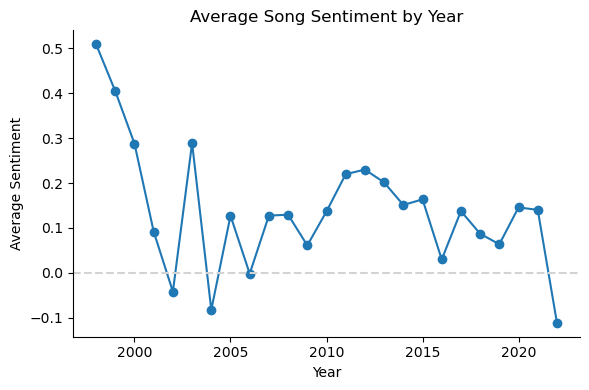

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

DOC_SENT_PLOT = DOC_SENT.reset_index().merge(
    LIB[['artist','song','year']],
    on = ['artist', 'song'],
    how='left'
)
DOC_SENT_PLOT = DOC_SENT_PLOT[DOC_SENT_PLOT['year']>=1998].copy()
YEAR_SENT = DOC_SENT_PLOT.groupby('year')['sentiment'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(YEAR_SENT['year'], YEAR_SENT['sentiment'], marker='o')
plt.axhline(0, color='lightgray', linestyle='--')
plt.title('Average Song Sentiment by Year')
plt.xlabel('Year')
plt.ylabel('Average Sentiment')
plt.tight_layout()
sns.despine()
plt.savefig('../images/Sentiment_Plot.png', bbox_inches='tight')
plt.show()

## VOCAB_W2V

In [76]:
from gensim.models import word2vec

sort_CORPUS = CORPUS.sort_index()
docs = sort_CORPUS.groupby(['artist','song']).term_str.apply(list).tolist()
w2v_params = dict(
    window = 2,
    vector_size = 200,
    min_count = 5,
    workers = 1,
    seed = 42
)
model = word2vec.Word2Vec(docs, **w2v_params)

WV = pd.DataFrame(model.wv.vectors, index=model.wv.index_to_key)
WV.index.name = 'term_str'

VOCAB_W2V = VOCAB.join(WV, how='left')
VOCAB_W2V.head(10)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


,n,n_chars,p,i,max_pos,max_pos_group,stop,porter_stem,df,idf,...,190,191,192,193,194,195,196,197,198,199
term_str,,,,,,,,,,,,,,,,,,,,,
0,185,1,1.330175e-04,12.876096,CD,OTHER,False,0,105.0,5.288921,...,-0.274235,0.433312,-0.009730,-0.071529,-0.154631,-0.043006,0.562354,0.566091,0.095221,-0.120937
00,41,2,2.947956e-05,15.049925,CD,OTHER,False,00,32.0,7.003167,...,-0.265229,0.205550,-0.018764,-0.159917,0.070303,-0.120830,0.244298,0.280998,0.232768,-0.075280
000,14,3,1.006619e-05,16.600122,CD,OTHER,False,000,6.0,9.418204,...,0.009144,0.075178,0.081456,-0.007966,-0.023257,0.008332,0.130051,0.097631,0.058702,-0.029114
00000,1,5,7.190137e-07,20.407477,CD,OTHER,False,00000,1.0,12.003167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
000s,1,4,7.190137e-07,20.407477,CD,OTHER,False,000,1.0,12.003167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
004,1,3,7.190137e-07,20.407477,CD,OTHER,False,004,1.0,12.003167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
005,4,3,2.876055e-06,18.407477,CD,OTHER,False,005,4.0,10.003167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
006,1,3,7.190137e-07,20.407477,CD,OTHER,False,006,1.0,12.003167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
007,3,3,2.157041e-06,18.822515,CD,OTHER,False,007,3.0,10.418204,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
VOCAB_W2V.to_csv('../data/VOCAB_W2V.csv', sep='|', index=True)

Document bag expressed in terms of OHCO levels: Song (at the artist -> song -> token level)

Number of features generated: 200

The library used to generate the embeddings: Gensim (Word2Vec)

## Word2vec tSNE Plot

In [78]:
from sklearn.manifold import TSNE as tsne

WV_plot = WV.head(500)
PP = 40 

tsne_engine = tsne(
    perplexity=PP, 
    n_components=2, 
    init='pca', 
    max_iter=2500, 
    random_state=42
)
TSNE = pd.DataFrame(
    tsne_engine.fit_transform(WV_plot), 
    columns=['x','y'], 
    index=WV_plot.index)

TSNE.index.name = 'term_str'

fig = px.scatter(TSNE.reset_index(), 'x', 'y', 
        text='term_str', 
        hover_name='term_str',  
        height=1000,
        width=1200)

fig.update_traces(
        mode='markers+text', 
        textfont=dict(color='black', size=14, family='Arial'),
        textposition='top center')

fig.write_image('../images/W2V_tSNE_Plot.png')
fig.show()

Describe a cluster in the plot that captures your attention:

One cluster that captured my attention was a group containing words related to the human body. This cluster included words such as hand, arms, lips, skin, head, heart, and eyes. This cluster suggests that the model learned that these words are used in similar contexts in song lyrics, likely when describing someone's appearance. As many pop songs are about love and relationships, a cluster of descriptors of a person is expected.